In [1]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile, os
zip_path = '/content/drive/MyDrive/FETAL_PLANES_ZENODO.zip'
extract_path = '/content/fetal_planes'
os.makedirs(extract_path, exist_ok=True)
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)
print("Done!")

Mounted at /content/drive
Extracting...
Done!


In [2]:
import os

extract_path = '/content/fetal_planes'

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print(' ' * level * 2 + os.path.basename(root) + '/')
    if level == 2:
        print(f"    ({len(files)} files)")

fetal_planes/
  Images/


In [3]:

for root, dirs, files in os.walk('/content/fetal_planes'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))
        if file.endswith('.png') or file.endswith('.jpg'):
            print("Sample image found:", os.path.join(root, file))
            break  # just show one example

/content/fetal_planes/FETAL_PLANES_DB_data.csv
Sample image found: /content/fetal_planes/Images/Patient01390_Plane2_1_of_1.png


In [4]:
import pandas as pd
csv_path = '/content/fetal_planes/FETAL_PLANES_DB_data.csv'
df = pd.read_csv(csv_path, sep=';')
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:\n", df['Plane'].value_counts())

                    Image_name  Patient_num  Plane  Brain_plane Operator  \
0  Patient00001_Plane1_1_of_15            1  Other  Not A Brain    Other   
1  Patient00001_Plane1_2_of_15            1  Other  Not A Brain    Other   
2  Patient00001_Plane1_3_of_15            1  Other  Not A Brain    Other   
3  Patient00001_Plane1_4_of_15            1  Other  Not A Brain    Other   
4  Patient00001_Plane1_5_of_15            1  Other  Not A Brain    Other   

  US_Machine  Train   
0      Aloka       1  
1      Aloka       1  
2      Aloka       1  
3      Aloka       1  
4      Aloka       1  

Shape: (12400, 7)

Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train ']

Class distribution:
 Plane
Other              4213
Fetal brain        3092
Fetal thorax       1718
Maternal cervix    1626
Fetal femur        1040
Fetal abdomen       711
Name: count, dtype: int64


In [6]:

df.columns = df.columns.str.strip()

print("Cleaned columns:", df.columns.tolist())
print("\nClass distribution:\n", df['Plane'].value_counts())
print("\nTrain/Test split:\n", df['Train'].value_counts())

Cleaned columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train']

Class distribution:
 Plane
Other              4213
Fetal brain        3092
Fetal thorax       1718
Maternal cervix    1626
Fetal femur        1040
Fetal abdomen       711
Name: count, dtype: int64

Train/Test split:
 Train
1    7129
0    5271
Name: count, dtype: int64


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

PyTorch: 2.10.0+cu128
GPU available: True
Using: cuda


In [9]:
class FetalPlanesDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.classes = sorted(df['Plane'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image_name'] + '.png')
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[row['Plane']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_dir = '/content/fetal_planes/Images'

df.columns = df.columns.str.strip()
train_df = df[df['Train'] == 1]
test_df  = df[df['Train'] == 0]

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

train_dataset = FetalPlanesDataset(train_df, img_dir, transform=train_transforms)
test_dataset  = FetalPlanesDataset(test_df,  img_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print("Classes:", train_dataset.class_to_idx)
print("Num classes:", NUM_CLASSES)

Train: 7129 | Test: 5271
Classes: {'Fetal abdomen': 0, 'Fetal brain': 1, 'Fetal femur': 2, 'Fetal thorax': 3, 'Maternal cervix': 4, 'Other': 5}
Num classes: 6


In [11]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
model = models.resnet50(weights=weights)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)
print("Model ready!")
print("Output classes:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Model ready!
Output classes: 6


In [12]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc  = 100. * correct / total
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = 100. * val_correct / val_total
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}]  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

    return history

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("=== Phase 1: Training FC head only (10 epochs) ===")
history1 = train_model(model, train_loader, test_loader,
                        criterion, optimizer, scheduler, epochs=10)

=== Phase 1: Training FC head only (10 epochs) ===
Epoch [01/10]  Train Loss: 0.8687  Acc: 69.72%  |  Val Loss: 0.7181  Acc: 73.76%
Epoch [02/10]  Train Loss: 0.6144  Acc: 77.51%  |  Val Loss: 0.6391  Acc: 76.34%
Epoch [03/10]  Train Loss: 0.5578  Acc: 79.80%  |  Val Loss: 0.6407  Acc: 76.97%
Epoch [04/10]  Train Loss: 0.5431  Acc: 80.57%  |  Val Loss: 0.5418  Acc: 79.57%
Epoch [05/10]  Train Loss: 0.5288  Acc: 80.95%  |  Val Loss: 0.5283  Acc: 80.44%
Epoch [06/10]  Train Loss: 0.5052  Acc: 81.83%  |  Val Loss: 0.5689  Acc: 79.42%
Epoch [07/10]  Train Loss: 0.4988  Acc: 82.10%  |  Val Loss: 0.5244  Acc: 80.74%
Epoch [08/10]  Train Loss: 0.5094  Acc: 81.40%  |  Val Loss: 0.5502  Acc: 79.32%
Epoch [09/10]  Train Loss: 0.5069  Acc: 82.30%  |  Val Loss: 0.5673  Acc: 79.00%
Epoch [10/10]  Train Loss: 0.5091  Acc: 82.13%  |  Val Loss: 0.5891  Acc: 78.54%


In [14]:
for param in model.parameters():
    param.requires_grad = True

In [15]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [16]:
print("Phase 2  Fine-tuning full model (10 epochs)")

history2 = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=10
)

Phase 2  Fine-tuning full model (10 epochs)
Epoch [01/10]  Train Loss: 0.3664  Acc: 87.49%  |  Val Loss: 0.3331  Acc: 87.92%
Epoch [02/10]  Train Loss: 0.2501  Acc: 91.72%  |  Val Loss: 0.2794  Acc: 90.29%
Epoch [03/10]  Train Loss: 0.1905  Acc: 93.11%  |  Val Loss: 0.2437  Acc: 91.50%
Epoch [04/10]  Train Loss: 0.1536  Acc: 94.80%  |  Val Loss: 0.2441  Acc: 91.73%
Epoch [05/10]  Train Loss: 0.1302  Acc: 95.48%  |  Val Loss: 0.2417  Acc: 92.41%
Epoch [06/10]  Train Loss: 0.1096  Acc: 95.99%  |  Val Loss: 0.2439  Acc: 92.37%
Epoch [07/10]  Train Loss: 0.0973  Acc: 96.61%  |  Val Loss: 0.2377  Acc: 92.58%
Epoch [08/10]  Train Loss: 0.0897  Acc: 96.86%  |  Val Loss: 0.2266  Acc: 92.98%
Epoch [09/10]  Train Loss: 0.0862  Acc: 97.05%  |  Val Loss: 0.2448  Acc: 92.79%
Epoch [10/10]  Train Loss: 0.0794  Acc: 97.22%  |  Val Loss: 0.2364  Acc: 92.87%


In [17]:
torch.save(model.state_dict(), "resnet50_fetal_planes.pth")

In [18]:
model.load_state_dict(torch.load("fetal_model.pth"))
model.eval()

test_img = "/content/fetal_planes/Images/PatientXXXX.png"

pred = predict_image(test_img, model, val_transforms)
print("Prediction:", pred)

FileNotFoundError: [Errno 2] No such file or directory: 'fetal_model.pth'

In [19]:
import os
os.listdir()

['.config',
 'fetal_planes',
 'resnet50_fetal_planes.pth',
 'drive',
 'sample_data']

In [21]:
from PIL import Image
import torch

def predict_image(image_path, model, transform):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return train_dataset.classes[pred.item()]

In [22]:
model.load_state_dict(torch.load("resnet50_fetal_planes.pth"))
model.eval()

test_img = '/content/fetal_planes/Images/Patient01390_Plane2_1_of_1.png'

pred = predict_image(test_img, model, val_transforms)
print("Prediction:", pred)

Prediction: Fetal abdomen


=== Classification Report ===
                 precision    recall  f1-score   support

  Fetal abdomen       0.87      0.89      0.88       358
    Fetal brain       0.98      0.99      0.99      1472
    Fetal femur       0.83      0.92      0.87       524
   Fetal thorax       0.88      0.92      0.90       660
Maternal cervix       0.99      0.99      0.99       645
          Other       0.92      0.86      0.89      1612

       accuracy                           0.93      5271
      macro avg       0.91      0.93      0.92      5271
   weighted avg       0.93      0.93      0.93      5271


=== Confusion Matrix ===
[[ 320    0    0   14    0   24]
 [   3 1459    1    4    1    4]
 [   0    0  484    0    0   40]
 [   4    1    0  610    0   45]
 [   1    0    0    0  641    3]
 [  39   24   99   66    3 1381]]


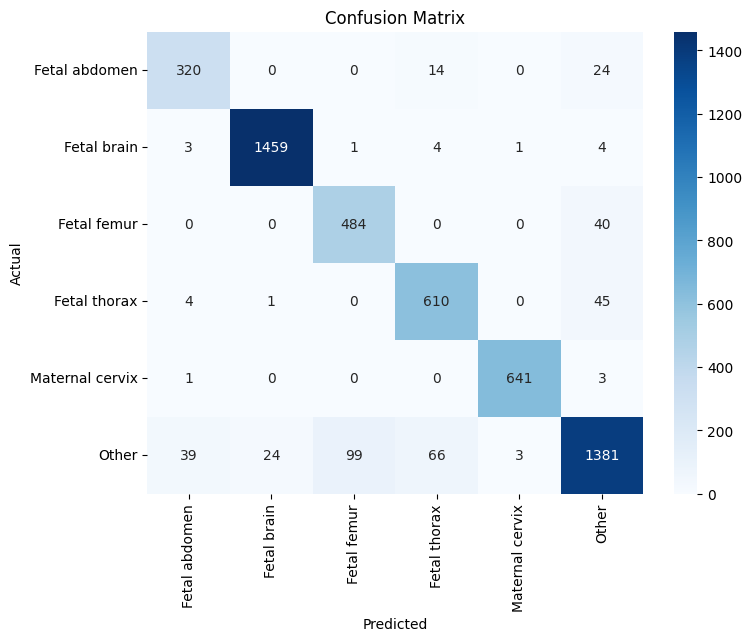

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
classes = ['Fetal abdomen', 'Fetal brain', 'Fetal femur',
           'Fetal thorax', 'Maternal cervix', 'Other']
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes))
cm = confusion_matrix(all_labels, all_preds)
print("\n=== Confusion Matrix ===")
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet50_fetal_planes.pth")

In [26]:
from google.colab import files
files.download("resnet50_fetal_planes.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>